# Digital Signal Processing - Proposed Exercises

# Chapter 1 - Part C
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lasseufpa/dsp/blob/main/notebooks/exercicios/exercises_1C.ipynb)

## Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1.5

The analog signal $x(t) = 2t \,\text{V}$ is digitized using a 2-bits ADC with sampling frequency $F_s = 100\,\text{Hz}$ to create a digital signal $x_q[n]$. Assuming the first sample is obtained at $t = 0\,\text{s}$, inform:

a) the values of the first four samples (just use here sampling, without quantization)

b) the values of $x_q[n]$ for $n = 0, \ldots, 3$ given that the ADC uses rounding and its output levels are ${-2\Delta, -\Delta, 0, \Delta}$, with $\Delta = 0.025\,\text{V}$.




## Resolution

Given

$$
x(t)=2t \text{ V}
$$

Sampling frequency: $F_s=100\text{ Hz}$


So the sampling period is:

$$
T_s=\frac{1}{F_s}=\frac{1}{100}=0.01\text{ s}
$$

The first sample is taken at (t=0), so: $t_n=nT_s=0.01n$


Thus the sampled signal before quantization is:

$$
x[n]=x(nT_s)=2(0.01n)=0.02n \text{ V}
$$

---

a) First four samples without quantization

For (n=0,1,2,3):

$(n=0) \Rightarrow x[0]=0.02(0)=0$


$(n=1) \Rightarrow x[1]=0.02(1)=0.02\text{ V}$


$(n=2) \Rightarrow x[2]=0.02(2)=0.04\text{ V}$


$(n=3) \Rightarrow x[3]=0.02(3)=0.06\text{ V}$


So the first four samples are: $x[0]=0,\quad x[1]=0.02,\quad x[2]=0.04,\quad x[3]=0.06\text{ V}$

---

b) Quantized values (x_q[n])

Given $\Delta=0.025\text{ V}$ and ADC output levels ${-2\Delta,-\Delta,0,\Delta}$


Substituting $\Delta=0.025$:

$$
{-0.05,-0.025,0,0.025} \text{V}
$$

##### For (n=0): (x[0]=0) the nearest level is 0

So:

$$
x_q[0]=0
$$

##### For (n=1): (x[1]=0.02) we can calculate the distances to the levels:

to (0): ($|0.02-0|=0.02$); to (0.025): ($|0.02-0.025|=0.005$)

Nearest is (0.025), so:

$$
x_q[1]=0.025
$$

##### For (n=2): (x[2]=0.04)

Distances:

to (0.025): ($|0.04-0.025|=0.015$); to (0): ($|0.04-0|=0.04$)

Nearest available level is (0.025), so:

$$
x_q[2]=0.025
$$

##### For (n=3): (x[3]=0.06)

Again, the available positive levels only go up to (0.025), so the nearest available level is 0.025.

Thus:

$$
x_q[3]=0.025
$$

## Exercicie 1.14
Four frequencies generated by an ideal piano (in Hz) are: A7 = 3520, A6 = 1760, A5 = 880 and A4 = 440. a) When a piano song is digitized with sampling frequency $F_s = 44100$ Hz, what are the digital angular frequencies in radians corresponding to A7 and A4 b) what should be the values of W1 and W2 such that the Matlab/Octave commands below

```Fs=44100; $Ts =1/Fs$; N=3/Ts; n=0:N-1; x= cos(W1*n)+ cos(W2*n); soundsc (x)```

generate 3 seconds of a sum of two cosines, corresponding to the frequencies A6 and A5, respectively, still assuming the given Fs? c) Repeat a) and b) for Fs = 2 kHz. d) Adopting Fs = 2 kHz brings any trouble? Explain you answer.

### Resolution
a) In pratical, the tone create by a perfect piano can be modeled  as:
$$x(t) = \cos(2\pi f t)$$
Were $f$ is the frequency of a tone. One way to discretize a signal is to replace $t = n T_s$, were $T_s = 1/F_s$. Then:

$$x[n] = \cos(2\pi f n T_s) = \cos \left(2\pi f n \frac{1}{F_s} \right)$$
$$x[n] = \cos\left(2\pi \frac{f}{F_s} n \right)$$

Now, we can see that discrete frequency for a given tone is: $\Omega = 2\pi \frac{f}{F_s}$, so we can replace the frequencies by its numerical values:

$$\Omega_{A7} = 2\pi \frac{3520}{44100} \approx 0.1596 \pi$$

$$\Omega_{A4} = 2\pi \frac{440}{44100} \approx 0.0199 \pi$$

b) In pratical place, the values of ```W1``` and ```W2``` are a final value of $\Omega_{A7}$ and $\Omega_{A4}$ turns $\pi$ in a numerical value and computing it:

$$W_1 = 0.5014$$
$$W_2 = 0.0625$$

## Question 1.15
An 8-bit ADC uses two's complement to produce binary numbers corresponding to integers in the range $[-128, 127]$. The ADC quantizer is uniform with a step size of $\Delta = 10 \text{ mV}$.

a) For the following input values $x[n] = [0, 1, -1.28, 1.28, 2]$, determine the binary output $x_b[n]$, its corresponding integer value $x_d[n]$, the decoded output $x_q[n]$, and the quantization error $e[n]$.

b) Repeat the procedure assuming the ADC uses a numbering scheme based on an offset of $2^{b-1} = 128$.

Integer Value ($x_d$): It is the rounding of the input voltage divided by the step size.$$x_d[n] = \text{round} \left( \frac{x[n]}{\Delta} \right)$$

Decoded Value ($x_q$): It is the reconstructed voltage from the integer value.$$x_q[n] = x_d[n] \cdot \Delta$$

Quantization Error ($e$): Difference between the reconstructed and the original values.$$e[n] = x_q[n] - x[n]$$

--- Question 1.15 a) Two's Complement ---
     Input x[n] |  Int Value x_d[n] |   Binary x_b[n] | Reconstructed x_q[n] |      Error e[n]
--------------------------------------------------------------------------------------------
          0.000 |                 0 | 00000000        |                0.000 |           0.000
          1.000 |               100 | 01100100        |                1.000 |           0.000
         -1.280 |              -128 | 10000000        |               -1.280 |           0.000
          1.280 |               127 | 01111111        |                1.270 |          -0.010
          2.000 |               127 | 01111111        |                1.270 |          -0.730

--- Question 1.15 b) Offset Binary ---
     Input x[n] |  Int Value x_d[n] |   Binary x_b[n] | Reconstructed x_q[n] |      Error e[n]
--------------------------------------------------------------------------------------------
          0.000 |               128 | 10000000        |            

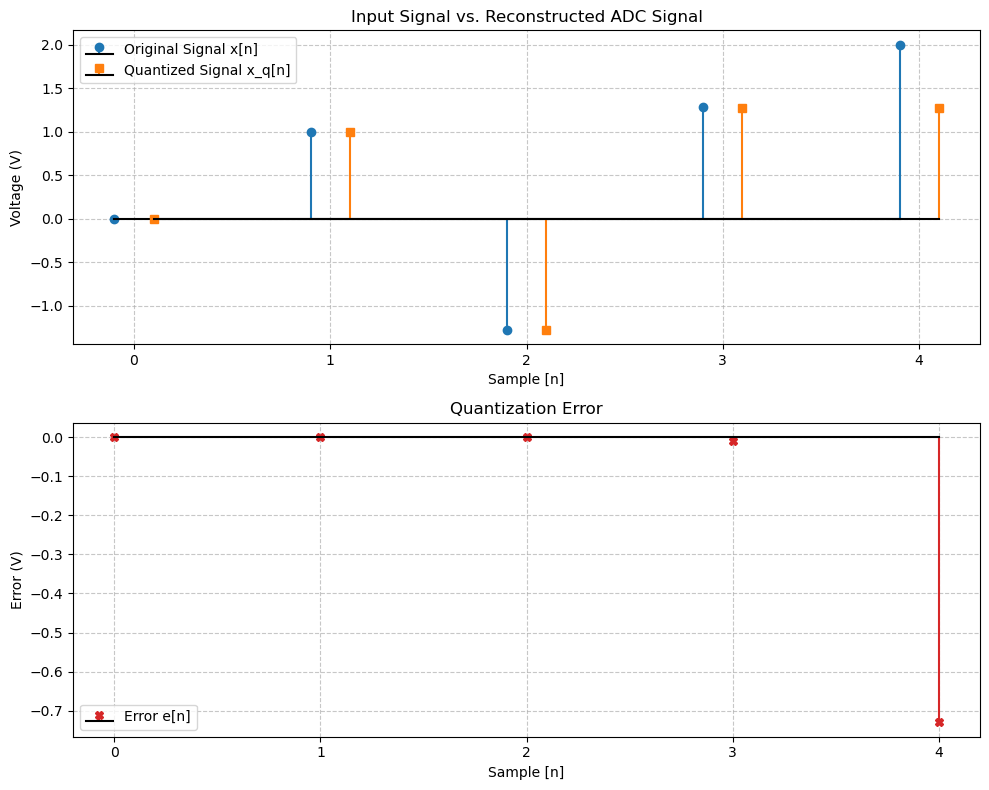

In [ ]:
b = 8
delta = 10e-3  # Step size: 10 mV = 0.01 V
x = np.array([0, 1, -1.28, 1.28, 2]) # Input 
n = np.arange(len(x))

# a) Standard Two's Complement quantization function
def quantize_twos_complement(x, delta, b):
    # Two's complement limits for a b-bit ADC
    n_min, n_max = -(2**(b-1)), (2**(b-1)) - 1 # [-128, 127]
    
    # x_d[n]:
    x_d = np.round(x / delta).astype(int)
    x_d = np.clip(x_d, n_min, n_max)
    
    # x_b[n]: Binary Add 2^b to negative numbers for two's complement binary
    x_b = [format(val if val >= 0 else val + (2**b), f'0{b}b') for val in x_d]
    
    # x_q[n]:
    x_q = x_d * delta
    
    # e[n]:
    e = x_q - x
    
    return x_d, x_b, x_q, e

# b) Offset Binary quantization function
def quantize_offset(x, delta, b):
    offset = 2**(b-1) # Offset of 128
    n_min, n_max = 0, (2**b) - 1 #[0, 255]
    
    # x_d[n]:
    x_d = np.round(x / delta).astype(int) + offset
    x_d = np.clip(x_d, n_min, n_max)
    
    # x_b[n]: Binary (All values after offset are non-negative)
    x_b = [format(val, f'0{b}b') for val in x_d]
    
    # x_q[n]:
    x_q = (x_d - offset) * delta
    
    # e[n]:
    e = x_q - x
    
    return x_d, x_b, x_q, e

# Calculating results
xd_a, xb_a, xq_a, e_a = quantize_twos_complement(x, delta, b)
xd_b, xb_b, xq_b, e_b = quantize_offset(x, delta, b)

# Displaying Numerical Results
print("--- Question 1.15 a) Two's Complement ---")
print(f"{'Input x[n]':>15} | {'Int Value x_d[n]':>17} | {'Binary x_b[n]':>15} | {'Reconstructed x_q[n]':>20} | {'Error e[n]':>15}")
print("-" * 92)
for i in range(len(x)):
    print(f"{x[i]:15.3f} | {xd_a[i]:17d} | {xb_a[i]:15s} | {xq_a[i]:20.3f} | {e_a[i]:15.3f}")

print("\n--- Question 1.15 b) Offset Binary ---")
print(f"{'Input x[n]':>15} | {'Int Value x_d[n]':>17} | {'Binary x_b[n]':>15} | {'Reconstructed x_q[n]':>20} | {'Error e[n]':>15}")
print("-" * 92)
for i in range(len(x)):
    print(f"{x[i]:15.3f} | {xd_b[i]:17d} | {xb_b[i]:15s} | {xq_b[i]:20.3f} | {e_b[i]:15.3f}")


# Visual Plotting of Results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Subplot 1: Original signal vs Quantized signal 
ax1.stem(n - 0.1, x, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Original Signal x[n]')
ax1.stem(n + 0.1, xq_a, linefmt='C1-', markerfmt='C1s', basefmt='k-', label='Quantized Signal x_q[n]')
ax1.set_title('Input Signal vs. Reconstructed ADC Signal')
ax1.set_xlabel('Sample [n]')
ax1.set_ylabel('Voltage (V)')
ax1.set_xticks(n)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Quantization error e[n]
ax2.stem(n, e_a, linefmt='C3-', markerfmt='C3X', basefmt='k-', label='Error e[n]')
ax2.set_title('Quantization Error')
ax2.set_xlabel('Sample [n]')
ax2.set_ylabel('Error (V)')
ax2.set_xticks(n)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Exercicise 1.16

A sinusoid $x[n] = \sin((π/3)n)$ was quantized with b = 3 bits per sample using
a step size $\Delta = 0.25$ and $X_{min} = -1$. This quantization generated the digital signal
$x_q[n]$. The corresponding binary values $x_b[n] = \tilde{Q}_c{x[n]}$ were stored in a file using
a numbering scheme with offset $2b-1 = 4$, but this file was wrongly interpreted with
a routine that generated $y_q[n]$ assuming a two's complement scheme. Inform the 6
values of a period of the original $x[n]$, the properly quantized $x_q[n]$ and the erroneously
interpreted $y_q[n]$.

In [3]:
# Step 1: Parameters
b = 3                     # bits per sample
delta = 0.25              # step size
Xmin = -1                 # minimum value
offset = 2**(b - 1) - 1   # offset scheme: 2^(b-1) - 1 = 4 for b=3

# Step 2: Original signal x[n] = sin((pi/3)n)
# We need one period: period = 2pi / (pi/3) = 6 samples
n = np.arange(6)          # m = 0, 1, 2, 3, 4, 5
x_n = np.sin((np.pi / 3) * n)

print("Original signal x[n] for n = 0 to 5:")
print(x_n)
print()

# Step 3: Quantization
# x_q[n] = Q_c{x[n]} with step delta and min Xmin
# Quantization levels: L = 2^b = 8 levels
# Quantization formula: round((z - Xmin) / delta) * delta + Xmin
x_q = np.round((x_n - Xmin) / delta) * delta + Xmin

print("Properly quantized x_q[n] (x_q[n] in the problem):")
print(x_q)
print()

# Step 4: Convert to index (0 to 2^b - 1) for offset binary
# First, compute index k = round((x_n - Xmin) / delta)
# This maps x_n to nearest quantization level index
k = np.round((x_n - Xmin) / delta).astype(int)

print("Quantization indices k (0 to 7):")
print(k)
print()

# Step 5: Apply offset binary: stored_value = k + offset
stored = k + offset
print("Binary stored values (with offset 4):")
print(stored)
print("Binary representation:")
for val in stored:
    print(f"{val:03b}", end=" ")
print("\n")

# Step 6: Wrong interpretation as two's complement
# Two's complement interpretation for b=3 bits:
# Range: -4 to 3 for 3-bit two's complement
# We have stored values 0-7, but misinterpreted as two's complement
# Function to interpret 3-bit two's complement
def twos_complement_3bit(binary_str):
    num = int(binary_str, 2)
    if num >= 4:  # if MSB is 1
        num = num - 8
    return num

# Get misinterpreted values
misinterpreted = []
for val in stored:
    binary_str = format(val, '03b')  # 3-bit binary
    misinterpreted.append(twos_complement_3bit(binary_str))

print("Erroneously interpreted y_q[m] (as two's complement):")
print(misinterpreted)
print()

# Step 7: Summary
print("=== FINAL RESULTS (one period m=0..5) ===")
print("n          :", list(n))
print("x[n]       :", [round(val, 4) for val in x_n])
print("x_q[n]     :", [round(val, 4) for val in x_q])
print("stored     :", list(stored))
print("y_q[n]     :", misinterpreted)

Original signal x[n] for n = 0 to 5:
[ 0.00000000e+00  8.66025404e-01  8.66025404e-01  1.22464680e-16
 -8.66025404e-01 -8.66025404e-01]

Properly quantized x_q[n] (x_q[n] in the problem):
[ 0.    0.75  0.75  0.   -0.75 -0.75]

Quantization indices k (0 to 7):
[4 7 7 4 1 1]

Binary stored values (with offset 4):
[ 7 10 10  7  4  4]
Binary representation:
111 1010 1010 111 100 100 

Erroneously interpreted y_q[m] (as two's complement):
[-1, 2, 2, -1, -4, -4]

=== FINAL RESULTS (one period m=0..5) ===
n          : [0, 1, 2, 3, 4, 5]
x[n]       : [0.0, 0.866, 0.866, 0.0, -0.866, -0.866]
x_q[n]     : [0.0, 0.75, 0.75, 0.0, -0.75, -0.75]
stored     : [7, 10, 10, 7, 4, 4]
y_q[n]     : [-1, 2, 2, -1, -4, -4]


## Exercicie 1.18

A 3-bit uniform quantizer has a step size $\Delta = 2\text{V}$. The input is $x$ and the output is $x_q$. Its minimum output value is $x_q = -8$. Assume four input values $[20, 0.7, -5.4, 6.1]\text{V}$ and inform:

a) The graph (“stairs”) showing $x_q$ vs $x$ for this quantizer.

b) The quantization error $e_q$ for each of these input values

c) The power in watts of $e_q$ considering only the four corresponding samples.

### Resolution
a) **1. Codebook Determination**
First, we determine the number of quantization levels (cardinality of the codebook) $M$. For a $b=3$ bits quantizer:
$$M = 2^b = 2^3 = 8 \text{ levels}$$

Given the step size $\Delta = 2\text{V}$ and the minimum output level $y_{min} = -8\text{V}$, the codebook $\mathcal{C}$ consists of 8 levels spaced by 2V:

$$
\mathcal{C} = \{-8, -6, -4, -2, 0, 2, 4, 6\}
$$

**2. Decision Boundaries (The "Stairs")**
To draw the graph, we define the input ranges that map to these output levels. For a uniform quantizer, the transition thresholds lie at the midpoint between adjacent levels ($Level \pm \Delta/2$).
Since $\Delta = 2$, the thresholds are at $\pm 1$ from the center of each level.

* **Linear Region:** The stairs rise in steps of 2V at inputs $x = \{-7, -5, -3, -1, 1, 3, 5\}$.
* **Saturation Region:**
    * Any input $x \geq 5$ saturates to the maximum level $6$.
    * Any input $x < -7$ saturates to the minimum level $-8$.

**3. Graph Generation**
We can visualize this staircase function and the specific points requested $[20, 0.7, -5.4, 6.1]$ using the following code:

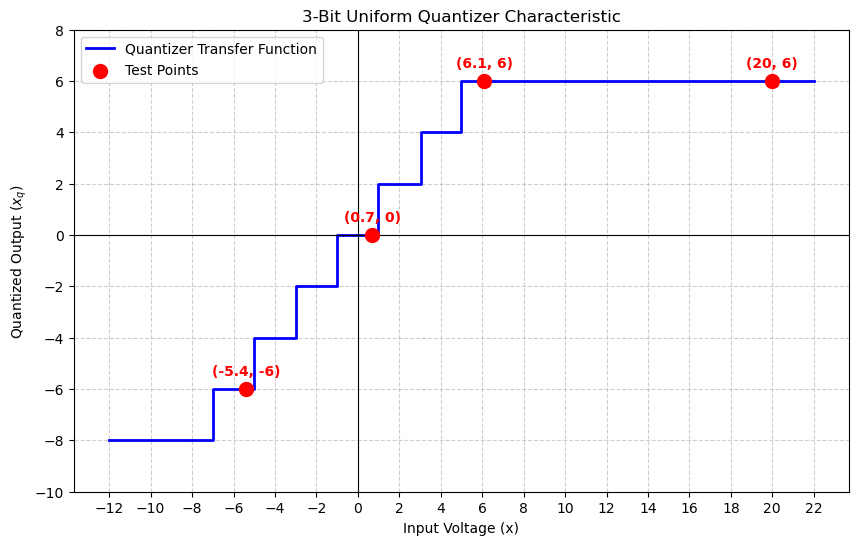

Specific Mappings:
Input: 20 V  ->  Output: 6 V
Input: 0.7 V  ->  Output: 0 V
Input: -5.4 V  ->  Output: -6 V
Input: 6.1 V  ->  Output: 6 V


In [4]:
def uniform_quantizer(x_val):
    levels = np.arange(8) * 2 - 8

    min_level = levels[0]  # -8
    max_level = levels[-1] # 6

    if x_val >= max_level + 1:
        return max_level
    if x_val <= min_level - 1:
        return min_level

    idx = (np.abs(levels - x_val)).argmin()
    return levels[idx]

x_continuous = np.linspace(-12, 22, 500)
y_quantized = [uniform_quantizer(x) for x in x_continuous]

plt.figure(figsize=(10, 6))

# Plot the Staircase
plt.step(x_continuous, y_quantized, where='mid', label='Quantizer Transfer Function', color='blue', linewidth=2)

# 3. Plot the specific points requested: [20, 0.7, -5.4, 6.1]
test_points = [20, 0.7, -5.4, 6.1]
test_outputs = [uniform_quantizer(p) for p in test_points]

plt.scatter(test_points, test_outputs, color='red', zorder=5, s=100, label='Test Points')

# Annotate the test points
for x, y in zip(test_points, test_outputs):
    plt.annotate(f'({x}, {y})', (x, y), xytext=(0, 10), textcoords='offset points', ha='center', color='red', fontweight='bold')

# Formatting
plt.title('3-Bit Uniform Quantizer Characteristic')
plt.xlabel('Input Voltage (x)')
plt.ylabel('Quantized Output ($x_q$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.yticks(np.arange(-10, 10, 2)) # Show ticks matching our step size
plt.xticks(np.arange(-12, 24, 2))
plt.legend()
plt.axhline(0, color='black', linewidth=0.8) # x-axis line
plt.axvline(0, color='black', linewidth=0.8) # y-axis line

plt.show()

# Print the specific mappings for verification
print("Specific Mappings:")
for inp, out in zip(test_points, test_outputs):
    print(f"Input: {inp} V  ->  Output: {out} V")

b) The quantization error is defined as the difference between the input signal and the quantized output:
$$e_q[n] \triangleq x[n] - x_q[n]$$

Using the codebook $\mathcal{C} = \{-8, -6, -4, -2, 0, 2, 4, 6\}$ derived in part (a), we map each input to its nearest level (or saturate if it exceeds the range):

| Input $x[n]$ (V) | Nearest Level $x_q[n]$ (V) | Calculation ($e_q = x - x_q$) | Error $e_q[n]$ (V) | Note |
| :--- | :--- | :--- | :--- | :--- |
| **20.0** | **6** | $20 - 6$ | **14.0** | **Saturation** (Input $> 7$) |
| **0.7** | **0** | $0.7 - 0$ | **0.7** | Rounding (closest to 0) |
| **-5.4** | **-6** | $-5.4 - (-6)$ | **0.6** | Rounding (closest to -6) |
| **6.1** | **6** | $6.1 - 6$ | **0.1** | **Saturation** (Input $> 7$) |

c) Given the quantization error vector calculated previously:
$$
\mathbf{e_q} = [14, \ 0.7, \ 0.6, \ 0.1] \, \text{V}
$$

The average power of the quantization error ($P_{e_q}$) is calculated as the mean of the squared errors (Mean Squared Error - MSE):

$$
P_{e_q} = \frac{1}{N} \sum_{n=1}^{N} (e_q[n])^2
$$

Substituting the values with $N=4$:

$$
P_{e_q} = \frac{1}{4} \left[ (14)^2 + (0.7)^2 + (0.6)^2 + (0.1)^2 \right]
$$

$$
P_{e_q} = \frac{1}{4} \left[ 196 + 0.49 + 0.36 + 0.01 \right]
$$

$$
P_{e_q} = \frac{196.86}{4}
$$

$$
\boxed{P_{e_q} = 49.215 \, \text{W}}
$$